# Regenerate and Resample the Empirical Noise PSD for 1 MHz

This notebook walks through a practical workflow for adapting the existing measured noise PSD, originally measured near 4 MHz sampling, to a new 1 MHz trace standard. It also compares the old random-phase noise idea against the newer Gaussian Fourier-bin implementation in `QP_simulator/noise_module/NoiseGenerator.py`.

The core distinction is:

- **PSD conversion** decides what one-sided noise spectrum should be used at 1 MHz.
- **Noise synthesis** decides how random traces are drawn from that spectrum.

The most rigorous input is still measured 1 MHz baseline data. The conversions here are controlled substitutes when only the old PSD is available.

## Physical Assumptions

A 1 MHz digitizer has a Nyquist frequency of 500 kHz. The old tutorial PSD extends to about 1.953 MHz, which corresponds to a 3.90625 MHz digitizer. When using the old PSD at 1 MHz, choose the assumption explicitly:

- `inband`: use only the old PSD below 500 kHz. This is appropriate if the new acquisition chain removes high-frequency noise before sampling.
- `alias_fold`: fold high-frequency noise into the 0-500 kHz band. This approximates a poor/no anti-alias filter case, but it only includes frequencies covered by the old PSD.
- `synthetic_resample`: generate old-rate Gaussian noise from the old PSD, resample it with `scipy.signal.resample_poly`, then re-estimate a 1 MHz PSD. This is operationally transparent but still assumes stationary Gaussian old noise and the resampling filter used here.

For publication-grade physical rigor, measure new 1 MHz noise-only baselines and a 1 MHz template with the real electronics chain.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, resample_poly

# Locate repository root whether the notebook is opened from repo root or this folder.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "QP_simulator").exists():
    repo_root = repo_root.parent

qp_dir = repo_root / "QP_simulator"
if str(qp_dir) not in sys.path:
    sys.path.insert(0, str(qp_dir))

from noise_module import NoiseGenerator
from noise_module.psd_resampling import (
    alias_fold_psd_density,
    inband_resample_psd_density,
    load_psd_density,
    save_psd_density,
    synthetic_resample_psd_density,
)

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

repo_root

PosixPath('/Users/wongdowling/Documents/noise-weighted-subspace-reconstruction')

## Configuration

Set the target trace length here. The output PSD must be regenerated whenever `TARGET_SAMPLES` changes, because the rFFT frequency grid spacing is `df = fs / N`.

In [2]:
OLD_PSD_PATH = repo_root / "TraceSimulator" / "tutorials" / "noise_psd_xray.npy"

SOURCE_FS = 3_906_250.0  # Hz, old standard inferred from the PSD Nyquist
TARGET_FS = 1_000_000.0  # Hz, new standard
TARGET_SAMPLES = 32_768  # change this to the new trace length

N_SYNTHETIC_TRACES_FOR_PSD = 64
N_VALIDATION_TRACES = 128
RNG_SEED = 20260625

OUTPUT_DIR = repo_root / "data" / "noise_sample" / "derived"
OUTPUT_PSD_PATH = OUTPUT_DIR / f"noise_psd_xray_1mhz_N{TARGET_SAMPLES}.npy"
OUTPUT_META_PATH = OUTPUT_PSD_PATH.with_suffix(".json")
WRITE_OUTPUT = True

print(f"old PSD: {OLD_PSD_PATH}")
print(f"target duration: {TARGET_SAMPLES / TARGET_FS * 1e3:.3f} ms")
print(f"target df: {TARGET_FS / TARGET_SAMPLES:.6g} Hz")
print(f"target Nyquist: {TARGET_FS / 2:.1f} Hz")

old PSD: /Users/wongdowling/Documents/noise-weighted-subspace-reconstruction/TraceSimulator/tutorials/noise_psd_xray.npy
target duration: 32.768 ms
target df: 30.5176 Hz
target Nyquist: 500000.0 Hz


## Load the Old PSD

The custom PSD convention used here is a two-row `.npy` array: `frequency_hz` and one-sided PSD density, with units like `ADC^2 / Hz`.

PSD bins: 16385
old frequency range: 0.000 to 1953125.055 Hz
old df near first bins: 119.209 Hz
old implied fs from Nyquist: 3906250.110476 Hz


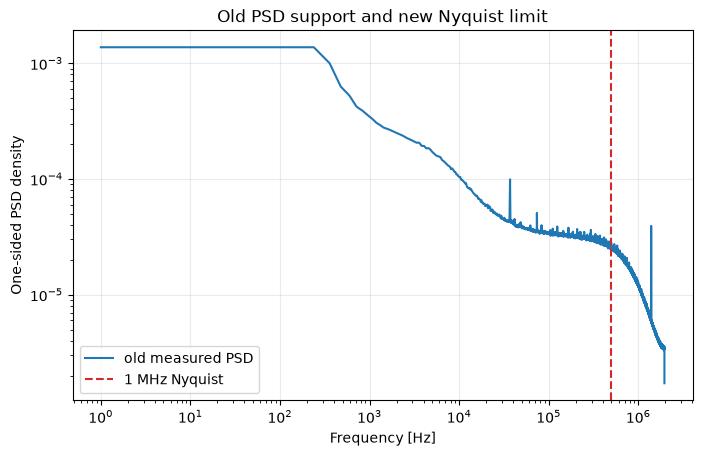

In [3]:
old_f, old_psd = load_psd_density(OLD_PSD_PATH)

print(f"PSD bins: {old_f.size}")
print(f"old frequency range: {old_f[0]:.3f} to {old_f[-1]:.3f} Hz")
print(f"old df near first bins: {np.median(np.diff(old_f[:20])):.6g} Hz")
print(f"old implied fs from Nyquist: {2 * old_f[-1]:.6f} Hz")

fig, ax = plt.subplots()
ax.loglog(np.maximum(old_f, 1.0), old_psd, lw=1.5, label="old measured PSD")
ax.axvline(TARGET_FS / 2, color="tab:red", ls="--", label="1 MHz Nyquist")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("One-sided PSD density")
ax.set_title("Old PSD support and new Nyquist limit")
ax.legend()
plt.show()

## Build Candidate 1 MHz PSDs

`inband` is usually the default surrogate if the new 1 MHz chain has proper anti-alias filtering. `alias_fold` is included to show what the PSD would look like if high-frequency old noise aliases into the new band. `synthetic_resample` constructs a Monte Carlo substitute by generating old-rate Gaussian noise and applying the time-domain resampling operation.

In [4]:
f_inband, psd_inband, meta_inband = inband_resample_psd_density(
    old_f,
    old_psd,
    target_sampling_frequency=TARGET_FS,
    target_samples=TARGET_SAMPLES,
)

f_alias, psd_alias, meta_alias = alias_fold_psd_density(
    old_f,
    old_psd,
    target_sampling_frequency=TARGET_FS,
    target_samples=TARGET_SAMPLES,
)

f_synth, psd_synth, meta_synth = synthetic_resample_psd_density(
    old_f,
    old_psd,
    source_sampling_frequency=SOURCE_FS,
    target_sampling_frequency=TARGET_FS,
    target_samples=TARGET_SAMPLES,
    n_traces=N_SYNTHETIC_TRACES_FOR_PSD,
    seed=RNG_SEED,
    average="mean",
)

print(json.dumps(meta_synth, indent=2))

{
  "method": "synthetic_resample",
  "source_sampling_frequency": 3906250.0,
  "target_sampling_frequency": 1000000.0,
  "target_samples": 32768,
  "source_samples": 130000,
  "source_edge_samples": 1000,
  "n_traces": 64,
  "resample_up": 32,
  "resample_down": 125,
  "welch_window": "hann",
  "welch_average": "mean",
  "welch_detrend": "constant",
  "seed": 20260625
}


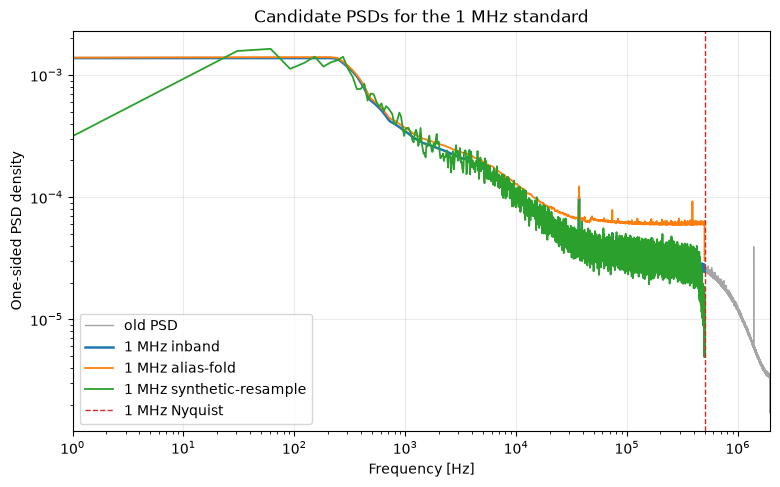

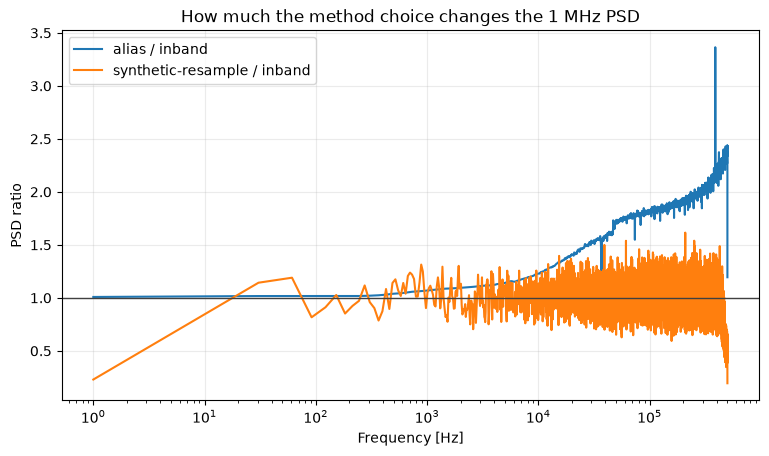

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.loglog(np.maximum(old_f, 1.0), old_psd, color="0.65", lw=1.0, label="old PSD")
ax.loglog(np.maximum(f_inband, 1.0), psd_inband, lw=1.8, label="1 MHz inband")
ax.loglog(np.maximum(f_alias, 1.0), psd_alias, lw=1.3, label="1 MHz alias-fold")
ax.loglog(np.maximum(f_synth, 1.0), psd_synth, lw=1.3, label="1 MHz synthetic-resample")
ax.axvline(TARGET_FS / 2, color="tab:red", ls="--", lw=1.0, label="1 MHz Nyquist")
ax.set_xlim(1.0, old_f[-1])
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("One-sided PSD density")
ax.set_title("Candidate PSDs for the 1 MHz standard")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.semilogx(np.maximum(f_inband, 1.0), psd_alias / np.maximum(psd_inband, np.finfo(float).tiny), label="alias / inband")
ax.semilogx(np.maximum(f_synth, 1.0), psd_synth / np.maximum(psd_inband, np.finfo(float).tiny), label="synthetic-resample / inband")
ax.axhline(1.0, color="0.25", lw=1.0)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("PSD ratio")
ax.set_title("How much the method choice changes the 1 MHz PSD")
ax.legend()
plt.show()

## Save the 1 MHz PSD

For normal TraceSimulator/QP `NoiseGenerator` use, save the two-row `[frequency_hz, psd_density]` file. The default below writes the `inband` PSD because that is the cleanest approximation when the real 1 MHz acquisition applies anti-alias filtering. Change `PSD_TO_SAVE` if you want to test another physical assumption.

In [6]:
PSD_TO_SAVE = "inband"  # options: "inband", "alias_fold", "synthetic_resample"

choices = {
    "inband": (f_inband, psd_inband, meta_inband),
    "alias_fold": (f_alias, psd_alias, meta_alias),
    "synthetic_resample": (f_synth, psd_synth, meta_synth),
}
save_f, save_psd, save_meta = choices[PSD_TO_SAVE]

if WRITE_OUTPUT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_psd_density(OUTPUT_PSD_PATH, save_f, save_psd)
    metadata = {
        **save_meta,
        "selected_method": PSD_TO_SAVE,
        "source_psd": str(OLD_PSD_PATH),
        "output_psd": str(OUTPUT_PSD_PATH),
        "trace_samples": TARGET_SAMPLES,
        "sampling_frequency_hz": TARGET_FS,
    }
    OUTPUT_META_PATH.write_text(json.dumps(metadata, indent=2, sort_keys=True) + "\n")
    print(f"wrote {OUTPUT_PSD_PATH}")
    print(f"wrote {OUTPUT_META_PATH}")
else:
    print("WRITE_OUTPUT is False; nothing saved.")

wrote /Users/wongdowling/Documents/noise-weighted-subspace-reconstruction/data/noise_sample/derived/noise_psd_xray_1mhz_N32768.npy
wrote /Users/wongdowling/Documents/noise-weighted-subspace-reconstruction/data/noise_sample/derived/noise_psd_xray_1mhz_N32768.json


## Generate Gaussian Noise from the 1 MHz PSD

`NoiseGenerator` expects a custom PSD file and internally converts the PSD density to rFFT coefficient power for the chosen trace length. For a custom PSD, `noise_power` is currently only a required config field; the absolute scale comes from the PSD file.

In [7]:
noise_config = {
    "noise_type": str(OUTPUT_PSD_PATH),
    "noise_power": 1.0,
    "sampling_frequency": TARGET_FS,
}

ng = NoiseGenerator(noise_config, seed=RNG_SEED + 1)
traces = np.stack([ng.generate_noise(TARGET_SAMPLES) for _ in range(N_VALIDATION_TRACES)])

t_ms = np.arange(TARGET_SAMPLES) / TARGET_FS * 1e3
freq_emp, psd_emp = welch(
    traces.reshape(-1),
    fs=TARGET_FS,
    window="hann",
    nperseg=TARGET_SAMPLES,
    noverlap=0,
    nfft=TARGET_SAMPLES,
    detrend="constant",
    return_onesided=True,
    scaling="density",
    average="mean",
)

print(f"generated traces shape: {traces.shape}")
print(f"mean trace std: {np.std(traces, axis=1).mean():.6g}")

generated traces shape: (128, 32768)
mean trace std: 4.27155


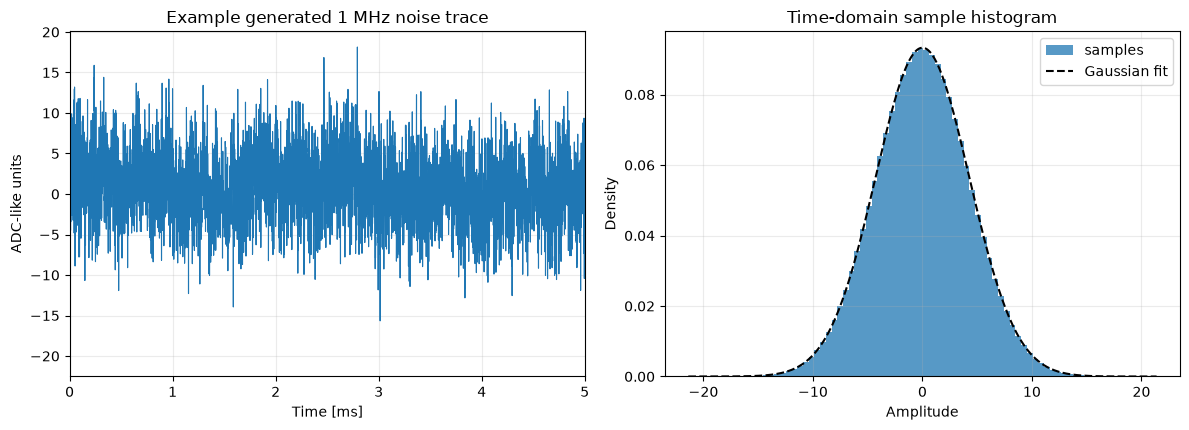

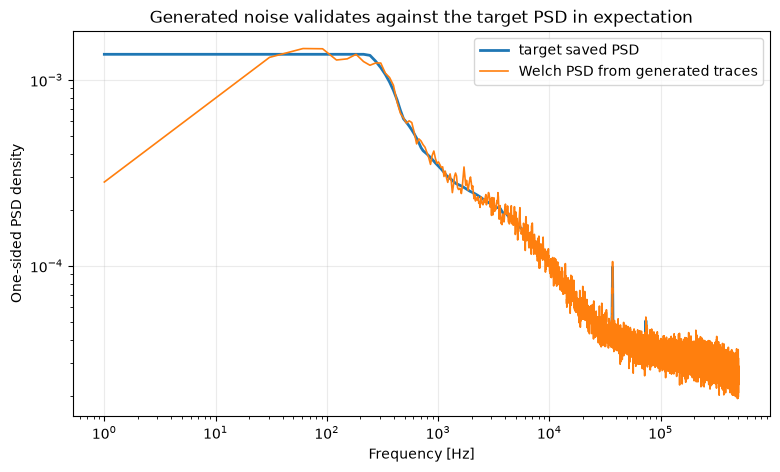

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].plot(t_ms, traces[0], lw=0.8)
axes[0].set_xlim(0, min(5.0, t_ms[-1]))
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("ADC-like units")
axes[0].set_title("Example generated 1 MHz noise trace")

axes[1].hist(traces.ravel(), bins=80, density=True, alpha=0.75, label="samples")
sigma = np.std(traces)
x = np.linspace(-5 * sigma, 5 * sigma, 400)
axes[1].plot(x, np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)), "k--", label="Gaussian fit")
axes[1].set_xlabel("Amplitude")
axes[1].set_ylabel("Density")
axes[1].set_title("Time-domain sample histogram")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(np.maximum(save_f, 1.0), save_psd, lw=2.0, label="target saved PSD")
ax.loglog(np.maximum(freq_emp, 1.0), psd_emp, lw=1.2, label="Welch PSD from generated traces")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("One-sided PSD density")
ax.set_title("Generated noise validates against the target PSD in expectation")
ax.legend()
plt.show()

## Why the Old Random-Phase Method Is Not Gaussian

The old TraceSimulator implementation used the pattern

```python
phi = uniform(0, 2*pi)
X_k = sqrt(P_k) * exp(1j * phi)
x = irfft(X_k)
```

That randomizes the **phase** but fixes the **magnitude** of every Fourier bin. Therefore each bin lies on a circle in the complex plane and every generated trace has the same periodogram amplitude per bin. Time-domain samples may look roughly bell-shaped because they are sums of many sinusoids, but the process is not a proper stationary Gaussian process.

The newer implementation uses

```python
X_k = sqrt(P_k) * (normal + 1j * normal) / sqrt(2)
```

for interior rFFT bins, with real Gaussian DC/Nyquist bins. That gives independent complex-Gaussian Fourier coefficients. The bin magnitude is Rayleigh-distributed and the bin power is exponentially distributed around the target mean, which is the expected finite-sample behavior of Gaussian stationary noise. Since each time sample is a linear combination of Gaussian variables, the resulting time-domain trace is Gaussian too.

In [9]:
def density_to_rfft_power(psd_density: np.ndarray, fs: float, n: int) -> np.ndarray:
    """Convert one-sided PSD density to expected rFFT coefficient power."""
    power = np.asarray(psd_density, dtype=float) * fs * n
    if n > 2:
        upper = n // 2 + 1 - (n + 1) % 2
        power[1:upper] *= 0.5
    return power


def old_random_phase_coefficients(power: float, size: int, rng: np.random.Generator) -> np.ndarray:
    phi = rng.uniform(0.0, 2.0 * np.pi, size=size)
    return np.sqrt(power) * np.exp(1j * phi)


def gaussian_coefficients(power: float, size: int, rng: np.random.Generator) -> np.ndarray:
    return np.sqrt(power) * (rng.standard_normal(size) + 1j * rng.standard_normal(size)) / np.sqrt(2.0)


rng = np.random.default_rng(RNG_SEED + 2)
power_grid = density_to_rfft_power(save_psd, TARGET_FS, TARGET_SAMPLES)
bin_index = int(np.searchsorted(save_f, 10_000.0))
bin_power = float(power_grid[bin_index])

n_coeff_samples = 6000
old_coeff = old_random_phase_coefficients(bin_power, n_coeff_samples, rng)
new_coeff = gaussian_coefficients(bin_power, n_coeff_samples, rng)

print(f"diagnostic frequency bin: {save_f[bin_index]:.2f} Hz")
print(f"target E[|X_k|^2]: {bin_power:.6g}")

diagnostic frequency bin: 10009.77 Hz
target E[|X_k|^2]: 1.70638e+06


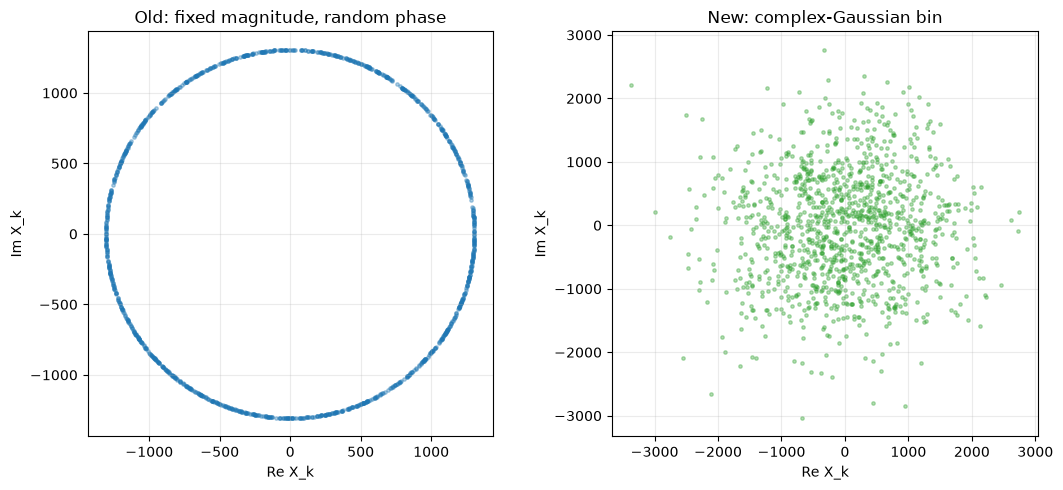

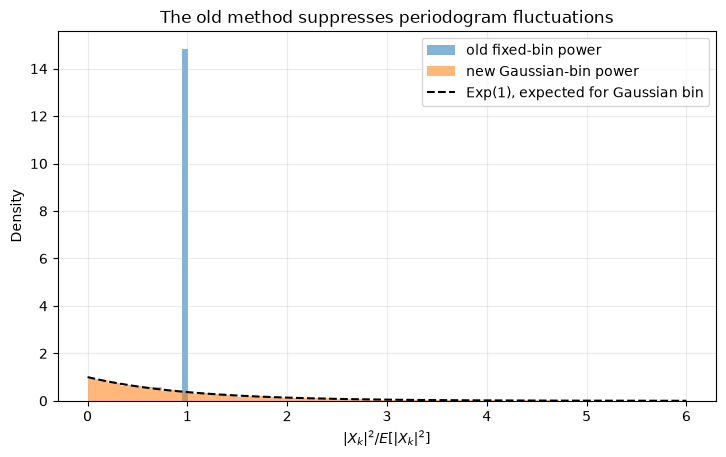

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sample = slice(None, 1200)
axes[0].scatter(old_coeff.real[sample], old_coeff.imag[sample], s=6, alpha=0.35)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Old: fixed magnitude, random phase")
axes[0].set_xlabel("Re X_k")
axes[0].set_ylabel("Im X_k")

axes[1].scatter(new_coeff.real[sample], new_coeff.imag[sample], s=6, alpha=0.35, color="tab:green")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("New: complex-Gaussian bin")
axes[1].set_xlabel("Re X_k")
axes[1].set_ylabel("Im X_k")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
old_norm_power = np.abs(old_coeff) ** 2 / bin_power
new_norm_power = np.abs(new_coeff) ** 2 / bin_power
bins = np.linspace(0, 6, 90)
ax.hist(old_norm_power, bins=bins, density=True, alpha=0.55, label="old fixed-bin power")
ax.hist(new_norm_power, bins=bins, density=True, alpha=0.55, label="new Gaussian-bin power")
x = np.linspace(0, 6, 400)
ax.plot(x, np.exp(-x), "k--", lw=1.5, label="Exp(1), expected for Gaussian bin")
ax.set_xlabel(r"$|X_k|^2 / E[|X_k|^2]$")
ax.set_ylabel("Density")
ax.set_title("The old method suppresses periodogram fluctuations")
ax.legend()
plt.show()

## Optional: Resample a Measured Template

I did not find a `maketemplate.py` file in this repository. If you have a measured 4 MHz template as a NumPy array, resample it with the same source and target sampling-rate ratio. For the old PSD rate, the ratio is exactly `1 MHz / 3.90625 MHz = 32 / 125`.

This operation is only physically faithful if the template represents the same analog chain and the resampling filter is a reasonable model of the 1 MHz anti-alias path.

In [11]:
def resample_measured_template(template_4mhz: np.ndarray, source_fs: float = SOURCE_FS, target_fs: float = TARGET_FS) -> np.ndarray:
    from fractions import Fraction

    ratio = Fraction(target_fs / source_fs).limit_denominator(100000)
    return resample_poly(np.asarray(template_4mhz, dtype=float), ratio.numerator, ratio.denominator)


# Example placeholder:
# template_4mhz = np.load("/path/to/measured_template_4mhz.npy")
# template_1mhz = resample_measured_template(template_4mhz)
# np.save("/path/to/measured_template_1mhz.npy", template_1mhz)

## Recommendation

Use the saved `inband` PSD as the default 1 MHz surrogate only if the 1 MHz acquisition has anti-alias filtering that removes noise above 500 kHz. Use `synthetic_resample` as a sensitivity check because it applies an explicit time-domain resampling operation. Treat `alias_fold` as a stress test for missing anti-alias suppression, not as the default.

The final rigorous replacement is simple: collect 1 MHz baseline traces, estimate the PSD directly at the new trace length, and compare it to the surrogate curves above.